# Website Traffic Forecasting

In [4]:
import os
os.getcwd()

'C:\\Users\\PC'

In [5]:
os.chdir(r"D:\FQL\PJ 4")

### Section 1 : Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

In [2]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
C = dict(blue='#1D4ED8', green='#15803D', red='#B91C1C', amber='#B45309', slate='#475569')
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
NUM_COLS = ['Page_Loads', 'Unique_Visits', 'First_Time_Visits', 'Returning_Visits']
print('All libraries loaded.')

All libraries loaded.


### Section 2 : Load Data

In [6]:
RAW_PATH = 'daily-website-visitors.csv'
df_raw = pd.read_csv(RAW_PATH)
print(f'Shape : {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

Shape : (2167, 8)
Columns: ['Row', 'Day', 'Day.Of.Week', 'Date', 'Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']


In [7]:
df_raw.head(8)

,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
0,1,Sunday,1,9/14/2014,"2,146","1,582","1,430",152
1,2,Monday,2,9/15/2014,"3,621","2,528","2,297",231
2,3,Tuesday,3,9/16/2014,"3,698","2,630","2,352",278
3,4,Wednesday,4,9/17/2014,"3,667","2,614","2,327",287
4,5,Thursday,5,9/18/2014,"3,316","2,366","2,130",236
5,6,Friday,6,9/19/2014,"2,815","1,863","1,622",241
6,7,Saturday,7,9/20/2014,"1,658","1,118",985,133
7,8,Sunday,1,9/21/2014,"2,288","1,656","1,481",175


### Section 3: Data Quality Report

In [8]:
report = pd.DataFrame({
    'dtype':   df_raw.dtypes,
    'nulls':   df_raw.isnull().sum(),
    'null_%':  (df_raw.isnull().mean()*100).round(2),
    'unique':  df_raw.nunique(),
})

In [10]:
print('======= Quality Report =======')
display(report)
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

======= Quality Report =======


,dtype,nulls,null_%,unique
Row,int64,0,0.0,2167
Day,object,0,0.0,7
Day.Of.Week,int64,0,0.0,7
Date,object,0,0.0,2167
Page.Loads,object,0,0.0,1756
Unique.Visits,object,0,0.0,1658
First.Time.Visits,object,0,0.0,1587
Returning.Visits,object,0,0.0,663


Duplicate rows: 0


In [11]:
print('\nDescriptive Stats:')
df_raw.describe()


Descriptive Stats:


,Row,Day.Of.Week
count,2167.000000,2167.000000
mean,1084.000000,3.997231
std,625.703338,2.000229
min,1.000000,1.000000
25%,542.500000,2.000000
50%,1084.000000,4.000000
75%,1625.500000,6.000000
max,2167.000000,7.000000


### Section 4 : Cleaning & Parsing

In [12]:
df = df_raw.copy()

# Normalize column names
df.columns = df.columns.str.strip().str.replace('.', '_', regex=False).str.replace(' ', '_')

In [13]:
# Strip commas from numeric columns
for col in NUM_COLS:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '', regex=False).astype(float)

In [14]:
# Parse dates
df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True)
df = df.sort_values('Date').reset_index(drop=True)

In [15]:
# Fill nulls
df[NUM_COLS] = df[NUM_COLS].fillna(method='ffill').fillna(method='bfill')

In [16]:
# Drop duplicate dates
df = df.drop_duplicates(subset='Date').reset_index(drop=True)

In [17]:
# Soft clip outliers (IQR x3) on Page_Loads
Q1, Q3 = df['Page_Loads'].quantile([0.25, 0.75])
IQR = Q3 - Q1
n_out = ((df['Page_Loads'] < Q1-3*IQR) | (df['Page_Loads'] > Q3+3*IQR)).sum()
df['Page_Loads'] = df['Page_Loads'].clip(lower=Q1-3*IQR, upper=Q3+3*IQR)
print(f'Outliers clipped: {n_out}')

Outliers clipped: 0


In [18]:
# Add helper columns
df['DayName'] = df['Date'].dt.day_name()

In [19]:
print(f'Cleaned shape  : {df.shape}')
print(f'Date range     : {df["Date"].min().date()} to {df["Date"].max().date()}')
df.head()

Cleaned shape  : (2167, 9)
Date range     : 2014-09-14 to 2020-08-19


,Row,Day,Day_Of_Week,Date,Page_Loads,Unique_Visits,First_Time_Visits,Returning_Visits,DayName
0,1,Sunday,1,2014-09-14,2146.0,1582.0,1430.0,152.0,Sunday
1,2,Monday,2,2014-09-15,3621.0,2528.0,2297.0,231.0,Monday
2,3,Tuesday,3,2014-09-16,3698.0,2630.0,2352.0,278.0,Tuesday
3,4,Wednesday,4,2014-09-17,3667.0,2614.0,2327.0,287.0,Wednesday
4,5,Thursday,5,2014-09-18,3316.0,2366.0,2130.0,236.0,Thursday


In [20]:
df.tail()

,Row,Day,Day_Of_Week,Date,Page_Loads,Unique_Visits,First_Time_Visits,Returning_Visits,DayName
2162,2163,Saturday,7,2020-08-15,2221.0,1696.0,1373.0,323.0,Saturday
2163,2164,Sunday,1,2020-08-16,2724.0,2037.0,1686.0,351.0,Sunday
2164,2165,Monday,2,2020-08-17,3456.0,2638.0,2181.0,457.0,Monday
2165,2166,Tuesday,3,2020-08-18,3581.0,2683.0,2184.0,499.0,Tuesday
2166,2167,Wednesday,4,2020-08-19,2064.0,1564.0,1297.0,267.0,Wednesday


### Section 5 : EDA

#### Time Series Analysis/Visuals

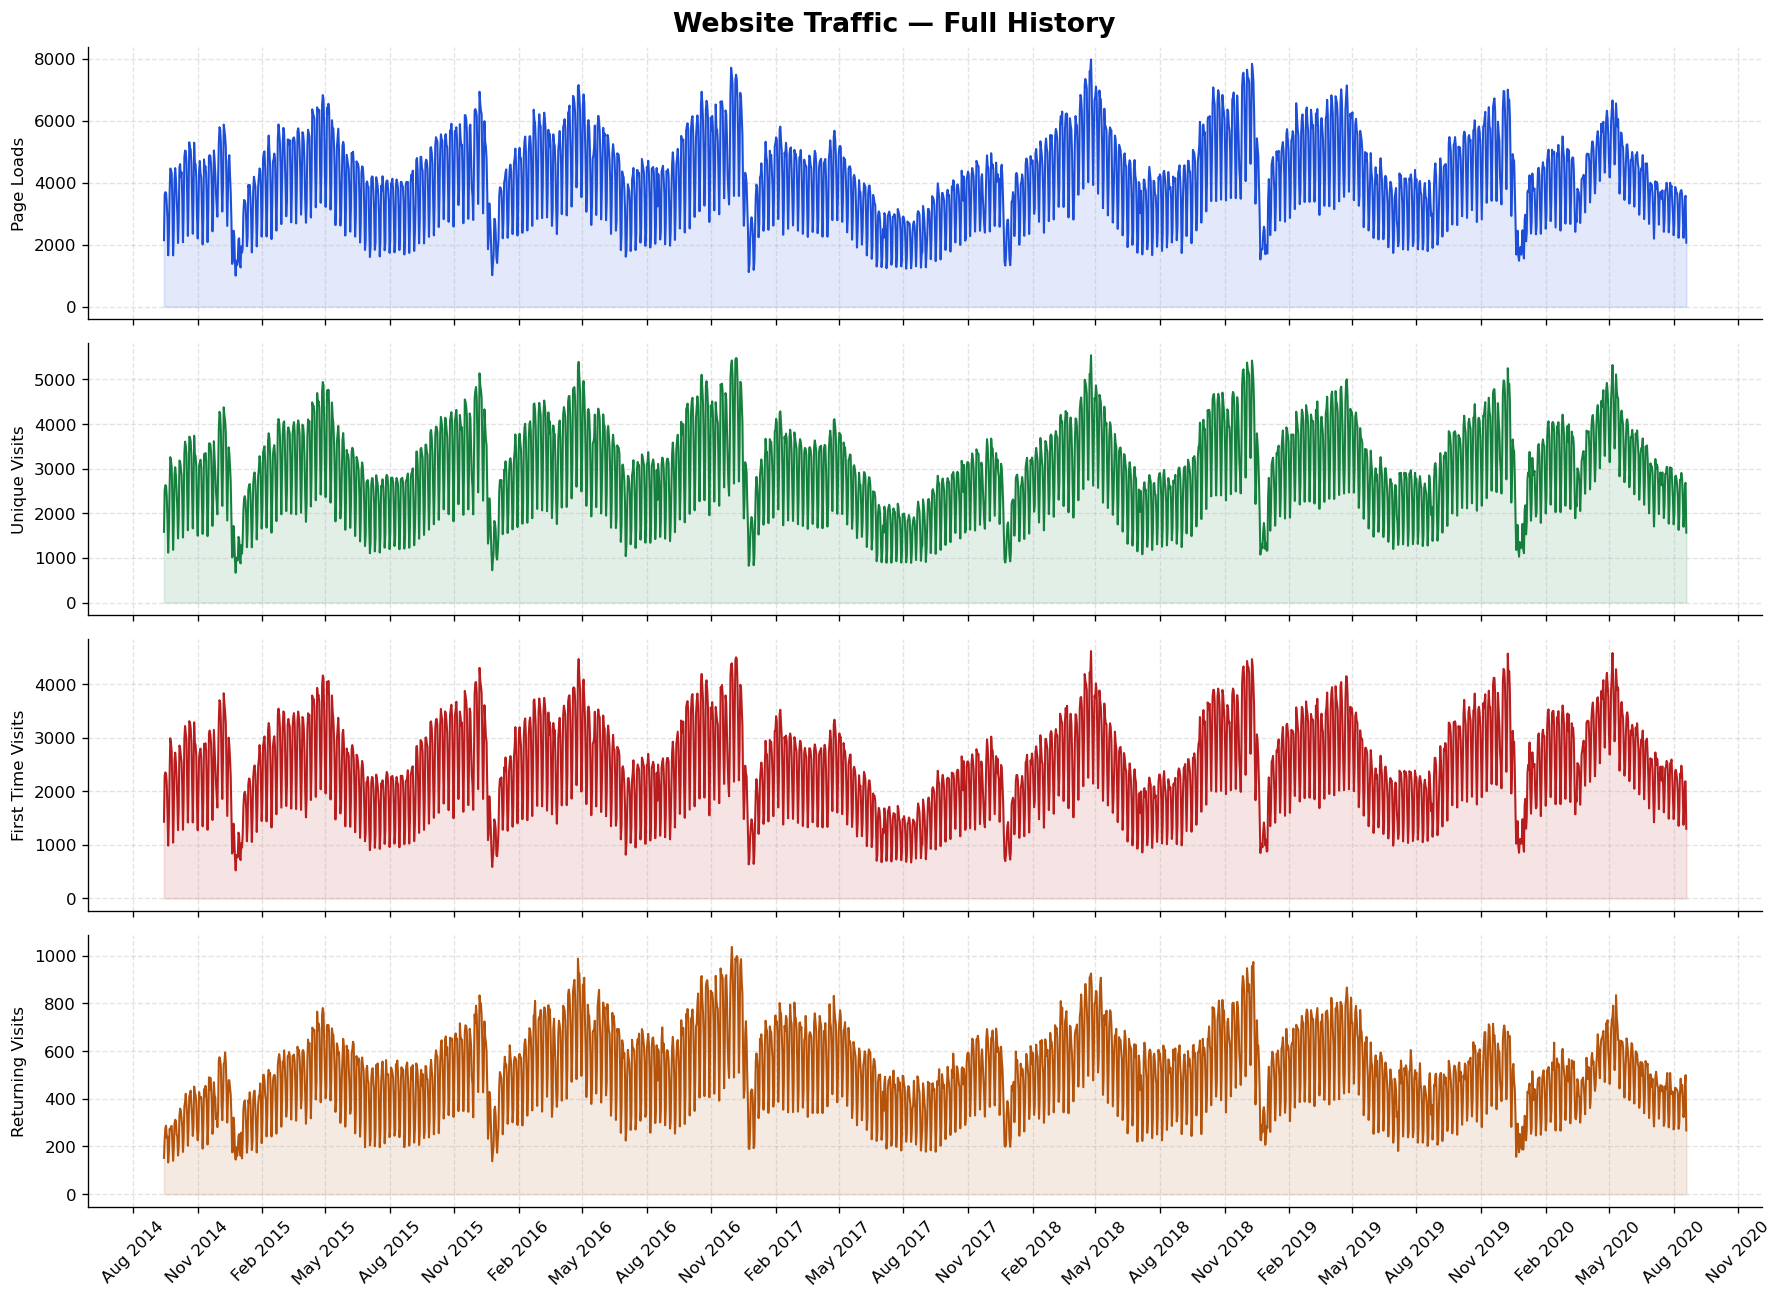

In [23]:
# 5.1 All metrics over time
colors = [C['blue'], C['green'], C['red'], C['amber']]
fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
fig.suptitle('Website Traffic — Full History', fontsize=16, fontweight='bold')
for ax, col, color in zip(axes, NUM_COLS, colors):
    ax.plot(df['Date'], df[col], lw=1.2, color=color)
    ax.fill_between(df['Date'], df[col], alpha=0.12, color=color)
    ax.set_ylabel(col.replace('_',' '), fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.35)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/01_all_metrics.png', bbox_inches='tight')
plt.show()

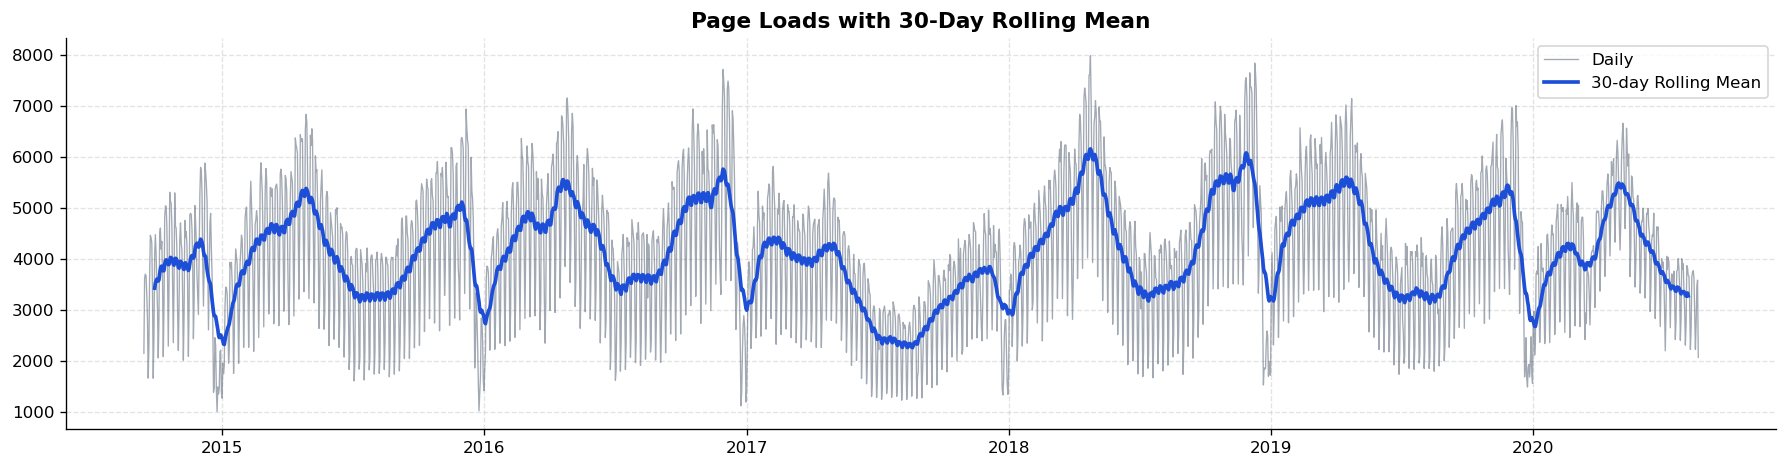

In [24]:
# 5.2 Rolling mean
df['roll30'] = df['Page_Loads'].rolling(30, center=True).mean()
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['Date'], df['Page_Loads'], lw=0.8, color=C['slate'], alpha=0.5, label='Daily')
ax.plot(df['Date'], df['roll30'], lw=2.2, color=C['blue'], label='30-day Rolling Mean')
ax.set_title('Page Loads with 30-Day Rolling Mean', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/02_rolling_mean.png', bbox_inches='tight')
plt.show()

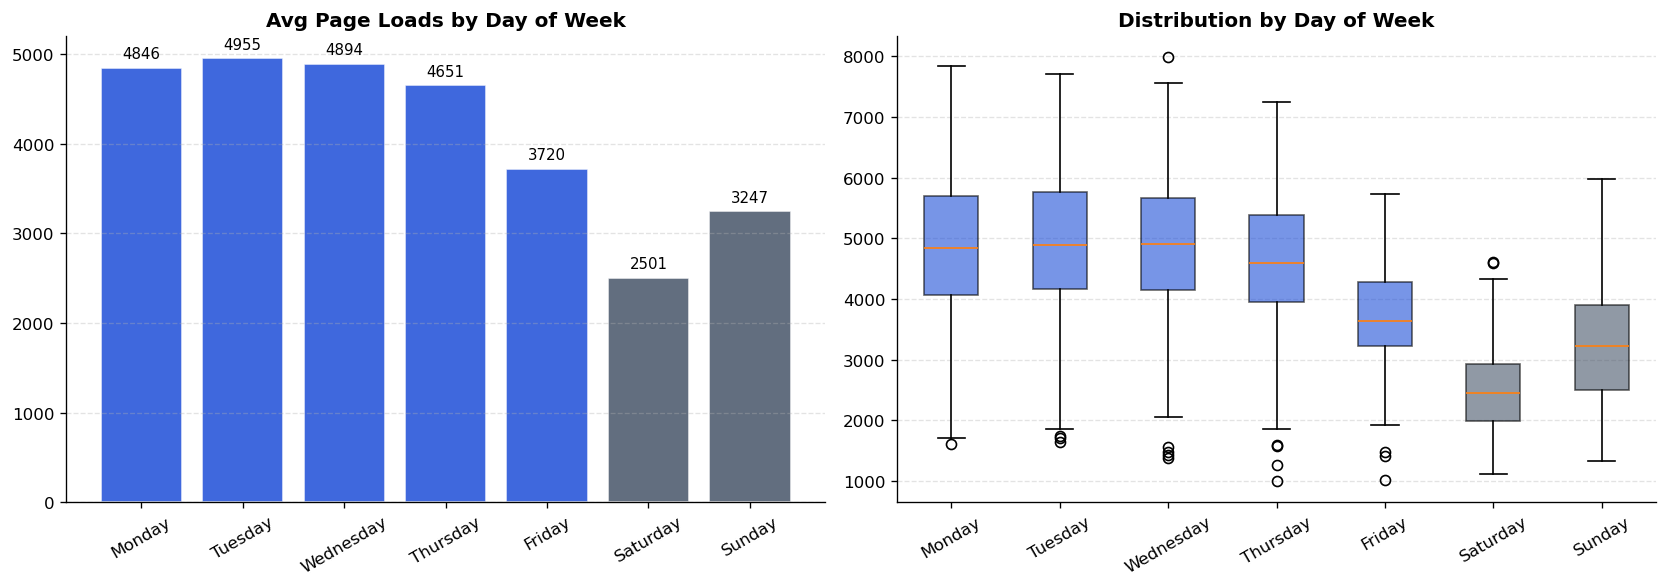

In [25]:
# 5.3 Day-of-week pattern
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats = df.groupby('DayName')['Page_Loads'].agg(['mean','median','std']).reindex(day_order)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = [C['blue'] if d not in ['Saturday','Sunday'] else C['slate'] for d in day_order]
bars = axes[0].bar(dow_stats.index, dow_stats['mean'], color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].bar_label(bars, fmt='%.0f', padding=4, fontsize=9)
axes[0].set_title('Avg Page Loads by Day of Week', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.35)
day_data = [df[df['DayName']==d]['Page_Loads'].values for d in day_order]
bp = axes[1].boxplot(day_data, patch_artist=True, labels=day_order)
for patch, bc in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(bc); patch.set_alpha(0.6)
axes[1].set_title('Distribution by Day of Week', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/03_dow_analysis.png', bbox_inches='tight')
plt.show()

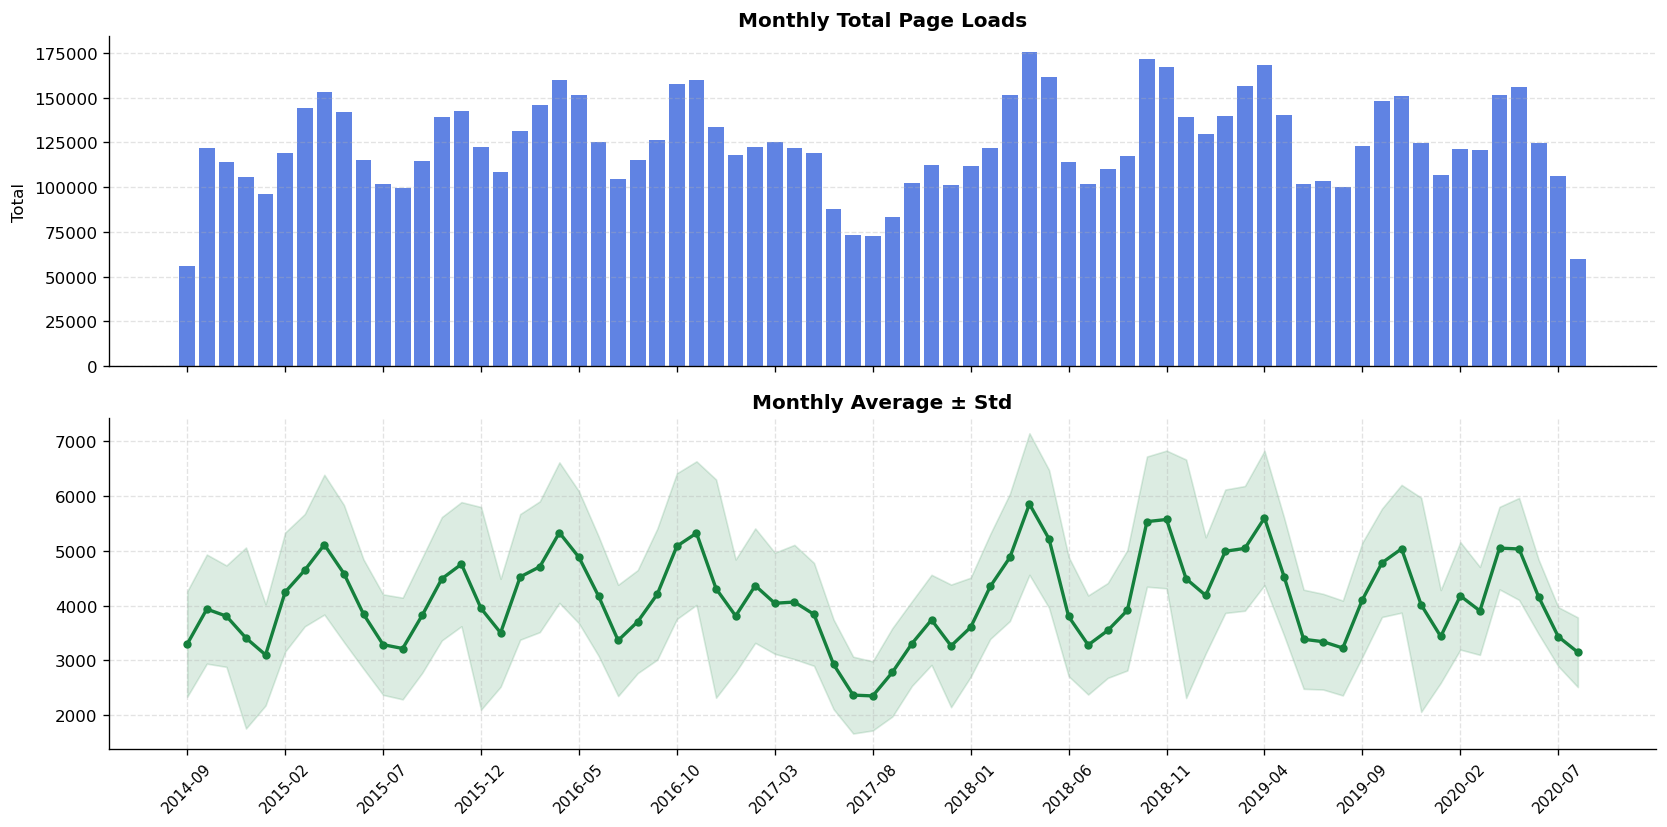

In [26]:
# 5.4 Monthly trend
df['YM'] = df['Date'].dt.to_period('M')
monthly = df.groupby('YM')['Page_Loads'].agg(['mean','sum','std'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
idx = range(len(monthly))
ax1.bar(idx, monthly['sum'], color=C['blue'], alpha=0.7)
ax1.set_title('Monthly Total Page Loads', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total'); ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax2.plot(idx, monthly['mean'], lw=2, color=C['green'], marker='o', markersize=4)
ax2.fill_between(idx, monthly['mean']-monthly['std'], monthly['mean']+monthly['std'], alpha=0.15, color=C['green'])
ax2.set_title('Monthly Average ± Std', fontsize=12, fontweight='bold')
step = max(1, len(monthly)//14)
ax2.set_xticks(list(idx)[::step])
ax2.set_xticklabels([str(m) for m in monthly.index[::step]], rotation=45, fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/04_monthly_trend.png', bbox_inches='tight')
plt.show()

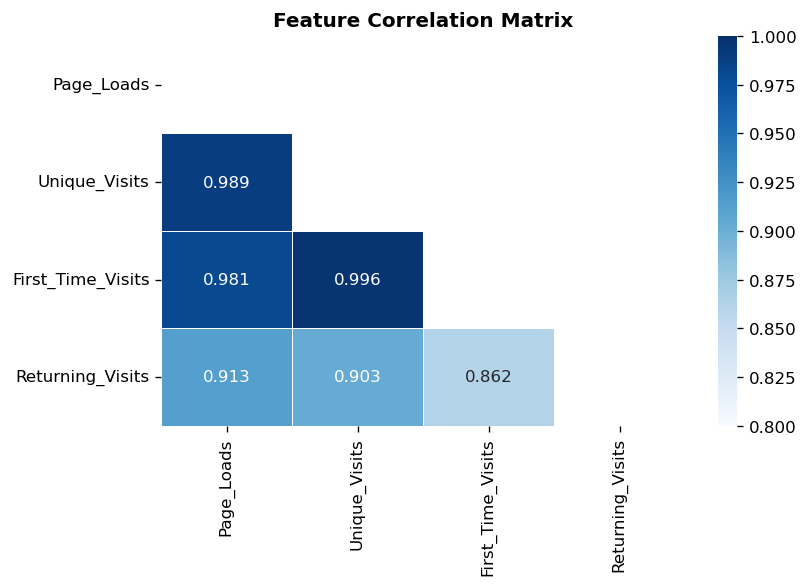

In [27]:
# 5.5 Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', ax=ax, mask=mask, vmin=0.8, vmax=1, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_correlation.png', bbox_inches='tight')
plt.show()

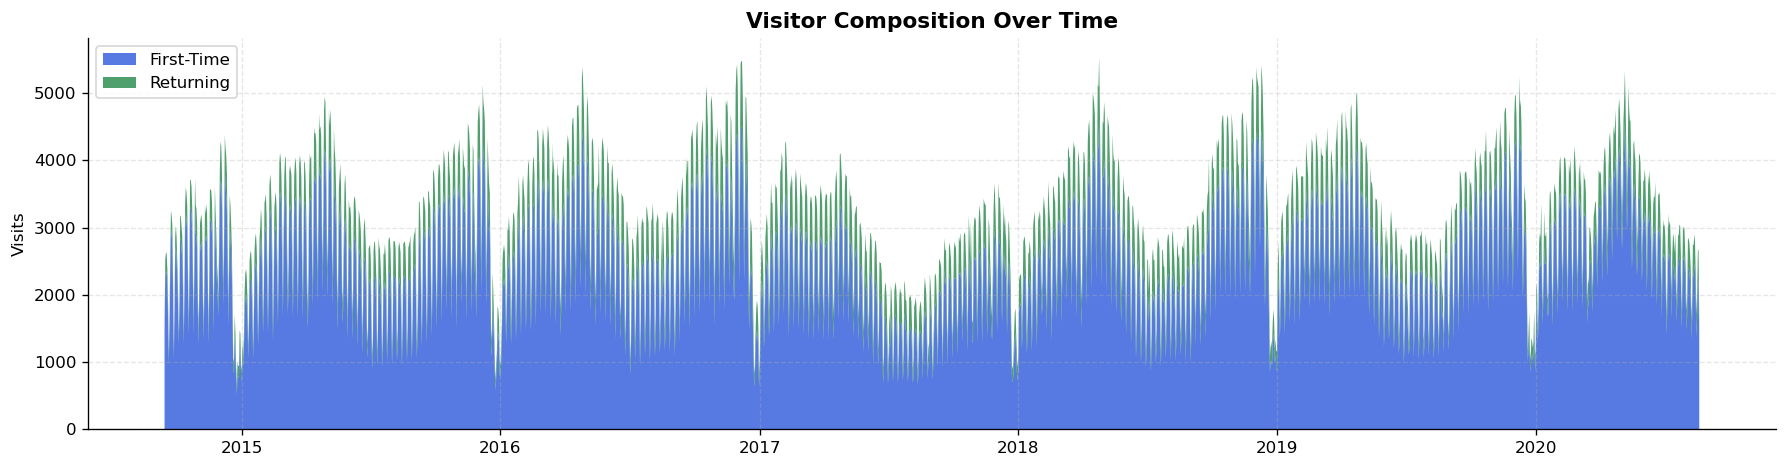

In [28]:
# 5.6 Visitor composition stacked area
fig, ax = plt.subplots(figsize=(15, 4))
ax.stackplot(df['Date'], df['First_Time_Visits'], df['Returning_Visits'],
             labels=['First-Time', 'Returning'], colors=[C['blue'], C['green']], alpha=0.75)
ax.set_title('Visitor Composition Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Visits'); ax.legend(loc='upper left'); ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/06_visitor_composition.png', bbox_inches='tight')
plt.show()

### Section 6 : Stationary Sets

In [29]:
series = df.set_index('Date')['Page_Loads']

In [30]:
def run_adf(s, label=''):
    r = adfuller(s.dropna())
    print(f'\n-- ADF [{label}]  stat={r[0]:.4f}  p={r[1]:.4f}')
    for k, v in r[4].items(): print(f'   CV {k}: {v:.4f}')
    print('   => STATIONARY' if r[1] < 0.05 else '   => NON-STATIONARY')
    return r[1] < 0.05

In [31]:
stat = run_adf(series, 'Original')
if not stat:
    run_adf(series.diff().dropna(), '1st-Diff')


-- ADF [Original]  stat=-4.2838  p=0.0005
   CV 1%: -3.4334
   CV 5%: -2.8629
   CV 10%: -2.5675
   => STATIONARY


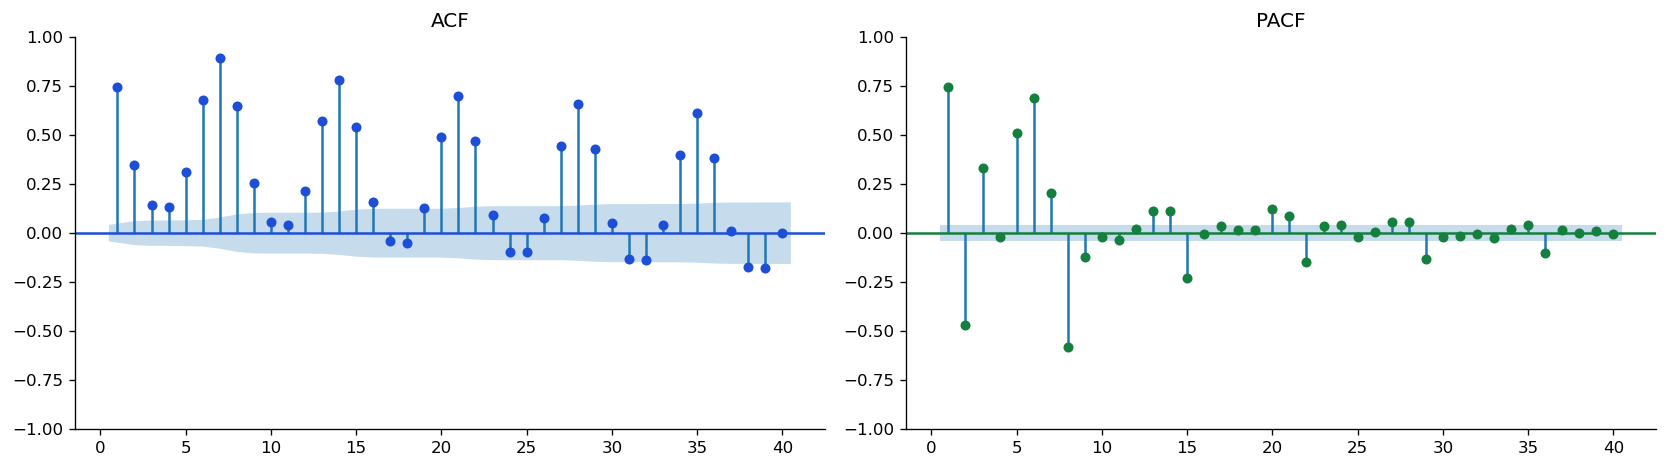

In [32]:
# ACF / PACF
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( series.dropna(), lags=40, ax=a1, color=C['blue'],  zero=False); a1.set_title('ACF')
plot_pacf(series.dropna(), lags=40, ax=a2, color=C['green'], zero=False); a2.set_title('PACF')
plt.tight_layout()
plt.savefig('plots/07_acf_pacf.png', bbox_inches='tight')
plt.show()

### Section 7 : Seasonal Decomposition

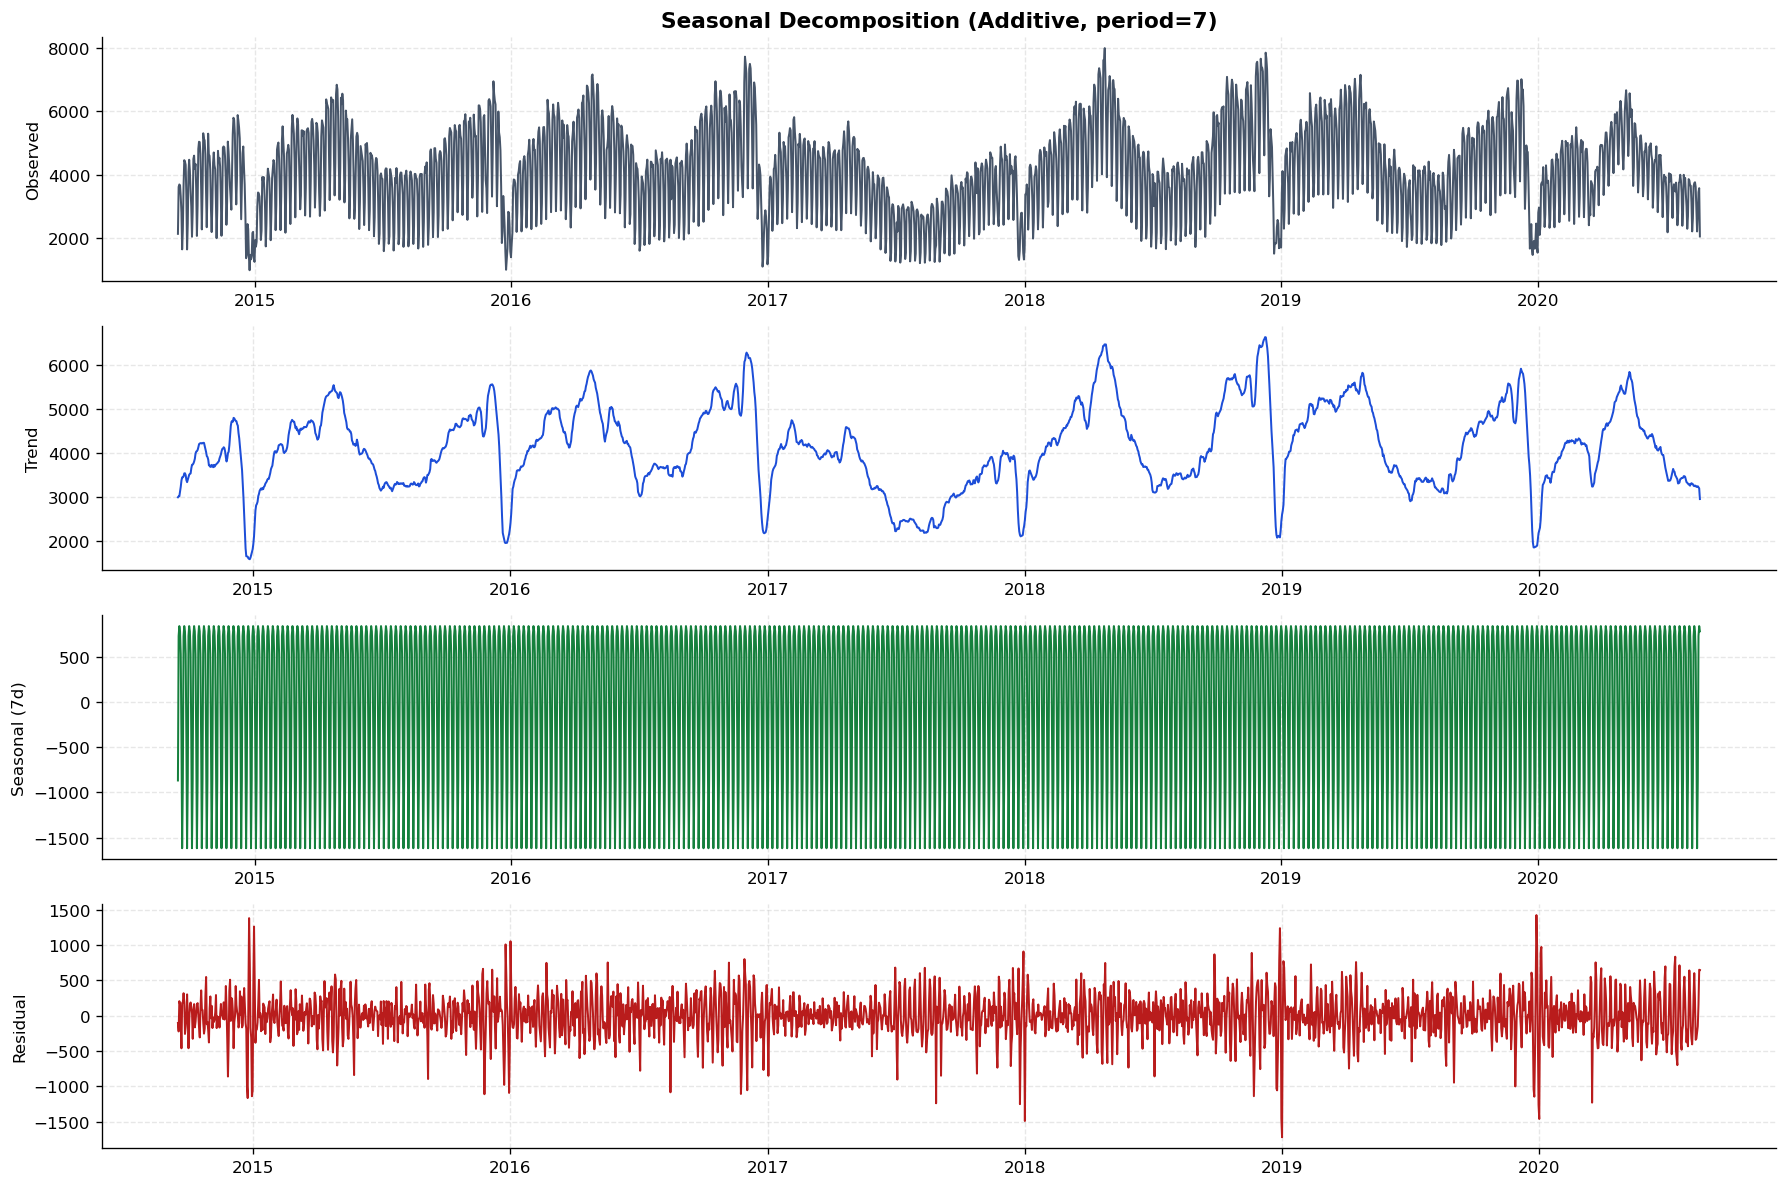

In [33]:
decomp = seasonal_decompose(series, model='additive', period=7)
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
for ax, (label, data), color in zip(axes,
    [('Observed', series), ('Trend', decomp.trend),
     ('Seasonal (7d)', decomp.seasonal), ('Residual', decomp.resid)],
    [C['slate'], C['blue'], C['green'], C['red']]):
    ax.plot(data.index, data.values, lw=1.2, color=color)
    ax.set_ylabel(label, fontsize=10); ax.grid(True, linestyle='--', alpha=0.3)
axes[0].set_title('Seasonal Decomposition (Additive, period=7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_decomposition.png', bbox_inches='tight')
plt.show()

### Section 8 : save processed data

In [34]:
OUT = 'data/processed_traffic.csv'
df[['Date'] + NUM_COLS + ['DayName']].to_csv(OUT, index=False)
print(f'Saved {OUT}  shape={df.shape}')

Saved data/processed_traffic.csv  shape=(2167, 11)


### 8. EDA Summary

In [39]:
from tabulate import tabulate

rows = [
    ['Weekly Seasonality', 'Day-of-week visualized; weekdays higher than weekends'],
    ['Trend',              'Upward trend via rolling mean; holiday dips in plots'],
    ['Stationarity',       'ADF: stat=−4.2838, p=0.0005 → Stationary; no differencing'],
    ['Visitor Mix',        'First-Time vs Returning via stacked area; no % computed'],
    ['Outliers',           'Soft-clipped 3×IQR on Page_Loads; 0 outliers clipped'],
    ['Feature Target',     'Page_Loads chosen as primary forecast target'],
]

print(tabulate(rows, headers=['Finding', 'Detail'], tablefmt='fancy_grid'))

╒════════════════════╤═══════════════════════════════════════════════════════════╕
│ Finding            │ Detail                                                    │
╞════════════════════╪═══════════════════════════════════════════════════════════╡
│ Weekly Seasonality │ Day-of-week visualized; weekdays higher than weekends     │
├────────────────────┼───────────────────────────────────────────────────────────┤
│ Trend              │ Upward trend via rolling mean; holiday dips in plots      │
├────────────────────┼───────────────────────────────────────────────────────────┤
│ Stationarity       │ ADF: stat=−4.2838, p=0.0005 → Stationary; no differencing │
├────────────────────┼───────────────────────────────────────────────────────────┤
│ Visitor Mix        │ First-Time vs Returning via stacked area; no % computed   │
├────────────────────┼───────────────────────────────────────────────────────────┤
│ Outliers           │ Soft-clipped 3×IQR on Page_Loads; 0 outliers clipped      │
├───